<a href="https://colab.research.google.com/github/crahulnaidu/quantum_computing/blob/main/month_1/month_1_day_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install qiskit
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 54.4 MB/s eta 0:00:00


In [20]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QFT
from qiskit.visualization import plot_histogram
import numpy as np



In [9]:
#Estimating the phase of T gate using phase estimation.

In [10]:
qpe=QuantumCircuit(4,3)
qpe.x(3)
qpe.draw()

q_0: ─────
          
q_1: ─────
          
q_2: ─────
     ┌───┐
q_3: ┤ X ├
     └───┘
c: 3/═════

In [11]:
for i in range(3):
  qpe.h(i)
qpe.draw()

┌───┐
q_0: ┤ H ├
     ├───┤
q_1: ┤ H ├
     ├───┤
q_2: ┤ H ├
     ├───┤
q_3: ┤ X ├
     └───┘
c: 3/═════

In [12]:
repetitions=1

for counting_qubit in range(3):
  for i in range(repetitions):
    qpe.cp(np.pi/4,counting_qubit,3)
  repetitions*=2

qpe.draw()

┌───┐                                                               
q_0: ┤ H ├─■─────────────────────────────────────────────────────────────
     ├───┤ │                                                             
q_1: ┤ H ├─┼────────■────────■───────────────────────────────────────────
     ├───┤ │        │        │                                           
q_2: ┤ H ├─┼────────┼────────┼────────■────────■────────■────────■───────
     ├───┤ │P(π/4)  │P(π/4)  │P(π/4)  │P(π/4)  │P(π/4)  │P(π/4)  │P(π/4) 
q_3: ┤ X ├─■────────■────────■────────■────────■────────■────────■───────
     └───┘                                                               
c: 3/════════════════════════════════════════════════════════════════════

In [18]:
qpe.barrier()

qpe.compose(QFT(3,inverse=True),[0,1,2])

qpe.barrier()

for i in range(3):
  qpe.measure(i,i)

qpe.draw()

/tmp/ipykernel_13195/309251829.py:3: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qpe.compose(QFT(3,inverse=True),[0,1,2])


┌───┐                                                                ░  ░ »
q_0: ┤ H ├─■──────────────────────────────────────────────────────────────░──░─»
     ├───┤ │                                                              ░  ░ »
q_1: ┤ H ├─┼────────■────────■────────────────────────────────────────────░──░─»
     ├───┤ │        │        │                                            ░  ░ »
q_2: ┤ H ├─┼────────┼────────┼────────■────────■────────■────────■────────░──░─»
     ├───┤ │P(π/4)  │P(π/4)  │P(π/4)  │P(π/4)  │P(π/4)  │P(π/4)  │P(π/4)  ░  ░ »
q_3: ┤ X ├─■────────■────────■────────■────────■────────■────────■────────░──░─»
     └───┘                                                                ░  ░ »
c: 3/══════════════════════════════════════════════════════════════════════════»
                                                                               »
«     ┌─┐       ░  ░  ░ ┌─┐      
«q_0: ┤M├───────░──░──░─┤M├──────
«     └╥┘┌─┐    ░  ░  ░ └╥┘┌─┐   
«q_1: ─╫─┤M├────░──░──░──╫─┤M├───
«      ║ └╥┘┌─┐ ░  ░  ░  ║ └╥┘┌─┐
«q_2: ─╫──╫─┤M├─░──░──░──╫──╫─┤M├
«      ║  ║ └╥┘ ░  ░  ░  ║  ║ └╥┘
«q_3: ─╫──╫──╫──░──░──░──╫──╫──╫─
«      ║  ║  ║  ░  ░  ░  ║  ║  ║ 
«c: 3/═╩══╩══╩═══════════╩══╩══╩═
«      0  1  2           0  1  2

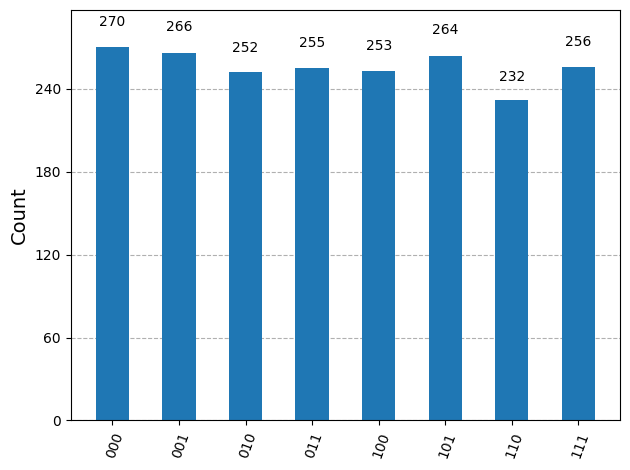

In [21]:
result=AerSimulator().run(qpe,shots=2048).result()

plot_histogram(result.get_counts())